In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Transient Detection in Strong Lenses with SBI

Amortized posterior on `transient_flux_frac` using `sbi.NPE` with a CNN embedding net.

- **Training data:** 10K paired clean / anomalous lens images from `data/`.
- **Parameter:** `theta = transient_flux_frac`, with `0` for clean images and the metadata value for anomalous ones.
- **Detection rule:** posterior mass above a small threshold given an observed image.
- **Bonus:** when a transient is detected, the same posterior also estimates its flux.

In [2]:
import json
import pickle
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
!pip install sbi
from sbi.inference import NPE
from sbi.neural_nets import posterior_nn
from sbi.utils import BoxUniform

DATA_DIR = Path('/content/drive/MyDrive/sbi-data')
ARTIFACTS_ROOT = DATA_DIR / 'artifacts'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ID = datetime.now().strftime('%Y%m%d-%H%M%S')
RUN_DIR = ARTIFACTS_ROOT / RUN_ID
print(f'this training run id = {RUN_ID}')

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'device = {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.8/517.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 34.6 MB/s eta 0:00:00
  Created wheel for nflows: filename=nflows-0.14-py3-none-any.whl size=53654 sha256=334a41845d1cd598cfe56c0ac9aa0c3df5e4f341fd300a490892fa86645dd702
  Stored in directory: /root/.cache/pip/wheels/fd/27/c3/8952205ea17b63dc1eaa24031e63111c6a3661cb22cc1e2a3c
Successfully built nflows
this training run id = 20260409-044102
device = cuda


## 1. Load data and build (theta, x) tensors

Each underlying lens system contributes two rows: one clean (theta=0) and one anomalous (theta=metadata flux frac). We split by **lens index** so the paired halves never straddle train/test.

In [3]:
clean = np.load(DATA_DIR / 'clean_images.npy')         # (N, 240, 240)
anom  = np.load(DATA_DIR / 'anomalous_images.npy')      # (N, 240, 240)
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

N = clean.shape[0]
assert anom.shape[0] == N == len(metadata)
flux_frac = np.array([m['transient_flux_frac'] for m in metadata], dtype=np.float32)
print(f'N = {N}, image shape = {clean.shape[1:]}, flux_frac range = [{flux_frac.min():.3f}, {flux_frac.max():.3f}]')

N = 10000, image shape = (240, 240), flux_frac range = [0.050, 0.150]


In [4]:
# Split by lens index so paired clean+anomalous of the same system stay together.
rng = np.random.default_rng(SEED)
perm = rng.permutation(N)
n_train = int(0.8 * N)
n_val   = int(0.1 * N)
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train + n_val]
test_idx  = perm[n_train + n_val:]
print(f'train/val/test lens systems: {len(train_idx)}/{len(val_idx)}/{len(test_idx)}')

train/val/test lens systems: 8000/1000/1000


In [5]:
STRETCH = 0.01  # ~ background noise scale

def stretch(images):
    return np.arcsinh(images / STRETCH).astype(np.float32)

# Single global affine fitted on training clean images and reused for every
# split (clean and anom), so the additive transient perturbation survives.
GLOBAL_MEAN = float(stretch(clean[train_idx]).mean())
GLOBAL_STD  = float(stretch(clean[train_idx]).std() + 1e-6)
print(f'GLOBAL_MEAN={GLOBAL_MEAN:.4f}, GLOBAL_STD={GLOBAL_STD:.4f}')

def normalize(images):
    return (stretch(images) - GLOBAL_MEAN) / GLOBAL_STD

def build_split(idx):
    x_clean = normalize(clean[idx])
    x_anom  = normalize(anom[idx])
    x = np.concatenate([x_clean, x_anom], axis=0)[:, None]  # (2*len(idx), 1, 240, 240)
    theta = np.concatenate([np.zeros(len(idx), dtype=np.float32), flux_frac[idx]])[:, None]
    return torch.from_numpy(theta), torch.from_numpy(x)

theta_train, x_train = build_split(train_idx)
theta_val,   x_val   = build_split(val_idx)
theta_test,  x_test  = build_split(test_idx)
print(f'x_train {tuple(x_train.shape)}, theta_train {tuple(theta_train.shape)}')

GLOBAL_MEAN=0.8404, GLOBAL_STD=1.2885
x_train (16000, 1, 240, 240), theta_train (16000, 1)


## 2. CNN embedding network

Maps the 240x240 image to a 64-D summary that `sbi` then feeds into the density estimator.

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, c_out)
        self.norm2 = nn.GroupNorm(8, c_out)
        self.pool = nn.AvgPool2d(2)
    def forward(self, x):
        x = F.gelu(self.norm1(self.conv1(x)))
        x = F.gelu(self.norm2(self.conv2(x)))
        return self.pool(x)

class LensEmbedding(nn.Module):
    """240 -> 120 -> 60 -> 30 -> 15 -> 7 -> Flatten -> MLP -> 128."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.blocks = nn.Sequential(
            ConvBlock(1, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 128),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.GELU(),
            nn.Linear(256, out_dim),
        )
    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)  # sbi sometimes passes (B, H, W)
        return self.head(self.blocks(x))

embedding_net = LensEmbedding(out_dim=128)
n_params = sum(p.numel() for p in embedding_net.parameters())
print(f'embedding net params: {n_params/1e6:.2f} M')

embedding net params: 2.23 M


## 3. Train NPE

Prior is `BoxUniform(0, 0.15)` so theta=0 is included. The training set already provides matched theta=0 examples (clean images), so the model learns a sharp mode there for non-transient inputs.

In [7]:
# Pretrain the embedding net as a binary clean-vs-anomalous classifier so it
# learns to separate the two classes before NPE sees it. NPE alone can fit the
# marginal p(theta) without ever using x; pretraining forces it to use x.
import time

embedding_net = embedding_net.to(DEVICE)
clf_head = nn.Linear(128, 1).to(DEVICE)

opt = torch.optim.Adam(
    list(embedding_net.parameters()) + list(clf_head.parameters()),
    lr=1e-3,
)

y_train_t = torch.from_numpy((theta_train.numpy().ravel() > 0).astype(np.float32))
y_val_t   = torch.from_numpy((theta_val.numpy().ravel()   > 0).astype(np.float32))

PRETRAIN_EPOCHS = 8
BATCH = 128

def iterate(x, y, batch, shuffle):
    n = len(x)
    idx = np.random.permutation(n) if shuffle else np.arange(n)
    for i in range(0, n, batch):
        sl = idx[i:i + batch]
        yield x[sl].to(DEVICE), y[sl].to(DEVICE)

t0 = time.time()
for epoch in range(1, PRETRAIN_EPOCHS + 1):
    embedding_net.train(); clf_head.train()
    tr_loss = tr_correct = tr_n = 0
    for xb, yb in iterate(x_train, y_train_t, BATCH, shuffle=True):
        logits = clf_head(embedding_net(xb)).squeeze(-1)
        loss = F.binary_cross_entropy_with_logits(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tr_loss += loss.item() * len(xb)
        tr_correct += ((logits > 0).float() == yb).sum().item()
        tr_n += len(xb)

    embedding_net.eval(); clf_head.eval()
    va_correct = va_n = 0
    with torch.no_grad():
        for xb, yb in iterate(x_val, y_val_t, BATCH, shuffle=False):
            logits = clf_head(embedding_net(xb)).squeeze(-1)
            va_correct += ((logits > 0).float() == yb).sum().item()
            va_n += len(xb)
    print(
        f'pretrain epoch {epoch:2d} | train_loss={tr_loss/tr_n:.4f} '
        f'| train_acc={tr_correct/tr_n:.3f} | val_acc={va_correct/va_n:.3f} '
        f'| {time.time() - t0:5.1f}s',
        flush=True,
    )

del clf_head, opt
embedding_net = embedding_net.cpu()

pretrain epoch  1 | train_loss=0.6997 | train_acc=0.493 | val_acc=0.500 |  10.3s
pretrain epoch  2 | train_loss=0.5195 | train_acc=0.668 | val_acc=0.980 |  19.2s
pretrain epoch  3 | train_loss=0.0663 | train_acc=0.980 | val_acc=0.987 |  28.2s
pretrain epoch  4 | train_loss=0.0456 | train_acc=0.987 | val_acc=0.994 |  37.2s
pretrain epoch  5 | train_loss=0.0333 | train_acc=0.990 | val_acc=0.996 |  46.1s
pretrain epoch  6 | train_loss=0.0300 | train_acc=0.991 | val_acc=0.992 |  55.0s
pretrain epoch  7 | train_loss=0.0270 | train_acc=0.991 | val_acc=0.996 |  64.0s
pretrain epoch  8 | train_loss=0.0299 | train_acc=0.991 | val_acc=0.995 |  72.9s


In [8]:
import warnings

# sbi runs a per-pixel quantile outlier check regardless of z_score_x; the
# bright arc pixels always trip it harmlessly. mps:0 -> mps is cosmetic.
warnings.filterwarnings('ignore', message='Data has extreme outliers')
warnings.filterwarnings('ignore', message=".*has device 'mps:0'.*")

prior = BoxUniform(low=torch.tensor([0.0]), high=torch.tensor([0.15]), device=DEVICE)

# z_score_x='none' because normalize() already standardizes; sbi's per-pixel
# z-score would destroy the spatial structure the embedding net needs.
density_estimator_build = posterior_nn(
    model='nsf',
    embedding_net=embedding_net,
    hidden_features=64,
    num_transforms=5,
    z_score_x='none',
)

inference = NPE(
    prior=prior,
    density_estimator=density_estimator_build,
    device=DEVICE,
    show_progress_bars=False,
)
# data_device='cpu' avoids OOM: append_simulations runs torch.quantile over
# the full (16000, 1, 240, 240) tensor and allocates several scratch copies.
inference = inference.append_simulations(theta_train, x_train, data_device='cpu')

# Patch sbi's epoch hook to print live train/val losses (default only prints
# the final epoch count).
_orig_summarize = inference._summarize_epoch
_t0 = time.time()

def _summarize_and_print(train_loss, val_loss, epoch_start_time, summarization_kwargs):
    _orig_summarize(train_loss, val_loss, epoch_start_time, summarization_kwargs)
    epoch = inference.epoch + 1   # sbi increments self.epoch *after* this call
    best  = inference._best_val_loss
    marker = '  *' if val_loss <= best else ''
    print(
        f'epoch {epoch:3d} | train_loss={train_loss:+.4f} | '
        f'val_loss={val_loss:+.4f} | best={best:+.4f} | '
        f'{time.time() - _t0:6.1f}s{marker}',
        flush=True,
    )

inference._summarize_epoch = _summarize_and_print

density_estimator = inference.train(
    training_batch_size=128,
    learning_rate=5e-4,
    validation_fraction=0.1,
    stop_after_epochs=15,
    max_num_epochs=200,
    show_train_summary=True,
)
posterior = inference.build_posterior(density_estimator)

epoch   1 | train_loss=-3.1855 | val_loss=-3.0886 | best=+inf |   14.5s  *
epoch   2 | train_loss=-2.8233 | val_loss=-3.9657 | best=-3.0886 |   26.6s  *
epoch   3 | train_loss=-3.0869 | val_loss=-3.8221 | best=-3.9657 |   38.7s
epoch   4 | train_loss=-3.4536 | val_loss=-4.6233 | best=-3.9657 |   50.8s  *
epoch   5 | train_loss=-3.9154 | val_loss=-2.8838 | best=-4.6233 |   62.9s
epoch   6 | train_loss=-2.3358 | val_loss=-3.0562 | best=-4.6233 |   75.0s
epoch   7 | train_loss=-2.8323 | val_loss=-3.5164 | best=-4.6233 |   87.2s
epoch   8 | train_loss=-3.4202 | val_loss=-4.2316 | best=-4.6233 |   99.3s
epoch   9 | train_loss=-2.7227 | val_loss=-2.4817 | best=-4.6233 |  111.3s
epoch  10 | train_loss=-2.6472 | val_loss=-4.2120 | best=-4.6233 |  123.5s
epoch  11 | train_loss=-1.9206 | val_loss=-2.3521 | best=-4.6233 |  135.6s
epoch  12 | train_loss=-1.7126 | val_loss=-2.0542 | best=-4.6233 |  147.8s
epoch  13 | train_loss=-1.7928 | val_loss=-2.2727 | best=-4.6233 |  159.9s
epoch  14 | train_l

In [9]:
RUN_DIR.mkdir(parents=True, exist_ok=True)

with open(RUN_DIR / 'posterior.pkl', 'wb') as f:
    pickle.dump(posterior, f)

torch.save(
    {'theta_test': theta_test, 'x_test': x_test, 'test_idx': test_idx},
    RUN_DIR / 'eval_bundle.pt',
)

with open(RUN_DIR / 'metadata.json', 'w') as f:
    json.dump({
        'run_id': RUN_ID,
        'seed': SEED,
        'best_val_loss': float(inference._best_val_loss),
        'epochs_trained': int(inference.epoch),
    }, f, indent=2)

(ARTIFACTS_ROOT / 'LATEST.txt').write_text(RUN_ID)

print(f'saved artifacts to {RUN_DIR}')
print(f'LATEST.txt -> {RUN_ID}')

saved artifacts to /content/drive/MyDrive/sbi-data/artifacts/20260409-044102
LATEST.txt -> 20260409-044102


## 4. Evaluate on the held-out test set

For each test image, draw posterior samples and compute the detection score `P(theta > eps | x)`.

In [10]:
# Set LOAD_RUN_ID to a specific folder name to evaluate that run; leave None
# to use whatever LATEST.txt points to.
LOAD_RUN_ID = None

if LOAD_RUN_ID is None:
    LOAD_RUN_ID = (ARTIFACTS_ROOT / 'LATEST.txt').read_text().strip()

LOAD_DIR = ARTIFACTS_ROOT / LOAD_RUN_ID
assert LOAD_DIR.exists(), f'no such run: {LOAD_DIR}'
print(f'loading run: {LOAD_RUN_ID}')
print(json.loads((LOAD_DIR / 'metadata.json').read_text()))

with open(LOAD_DIR / 'posterior.pkl', 'rb') as f:
    posterior = pickle.load(f)

bundle = torch.load(LOAD_DIR / 'eval_bundle.pt', weights_only=False)
theta_test = bundle['theta_test']
x_test     = bundle['x_test']
test_idx   = bundle['test_idx']
print('loaded posterior and eval bundle')

loading run: 20260409-044102
{'run_id': '20260409-044102', 'seed': 0, 'best_val_loss': -4.623348832130432, 'epochs_trained': 19}
loaded posterior and eval bundle


In [11]:
EPS = 0.01      # transient flux threshold
N_SAMPLES = 500

def detection_scores(x_batch):
    scores = np.zeros(len(x_batch), dtype=np.float32)
    medians = np.zeros(len(x_batch), dtype=np.float32)
    for i in range(len(x_batch)):
        x_i = x_batch[i].to(DEVICE)
        samples = posterior.sample((N_SAMPLES,), x=x_i, show_progress_bars=False)
        s = samples.detach().cpu().numpy().ravel()
        scores[i]  = float((s > EPS).mean())
        medians[i] = float(np.median(s))
    return scores, medians

scores, medians = detection_scores(x_test)
labels = (theta_test.numpy().ravel() > 0).astype(np.int32)
print(f'mean score (clean) = {scores[labels==0].mean():.3f}  std = {scores[labels==0].std():.3f}')
print(f'mean score (anom)  = {scores[labels==1].mean():.3f}  std = {scores[labels==1].std():.3f}')

mean score (clean) = 0.186  std = 0.019
mean score (anom)  = 0.969  std = 0.128


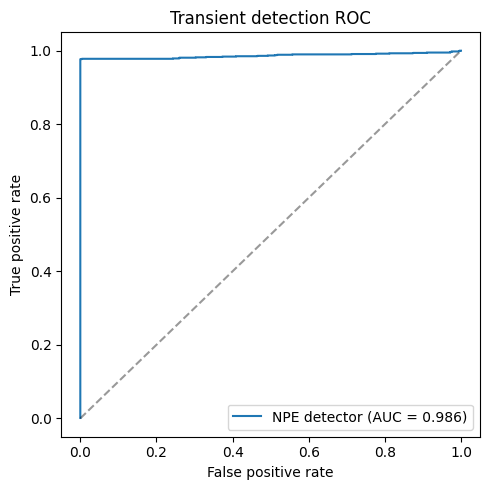

In [12]:
# ROC curve (no sklearn dependency).
def roc_curve(y_true, y_score):
    order = np.argsort(-y_score)
    y_true = y_true[order]
    tps = np.cumsum(y_true)
    fps = np.cumsum(1 - y_true)
    tpr = tps / max(y_true.sum(), 1)
    fpr = fps / max((1 - y_true).sum(), 1)
    auc = float(np.trapezoid(tpr, fpr))
    return fpr, tpr, auc

fpr, tpr, auc = roc_curve(labels, scores)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'NPE detector (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Transient detection ROC')
plt.legend()
plt.tight_layout()
plt.show()

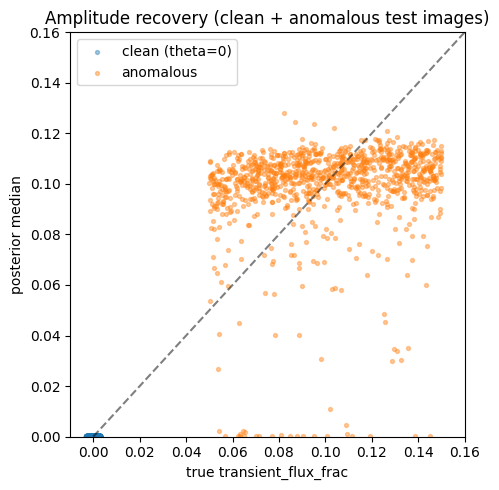

In [13]:
# Amplitude recovery: posterior median vs true flux frac, clean + anomalous.
true_anom = theta_test.numpy().ravel()[labels == 1]
pred_anom = medians[labels == 1]
pred_clean = medians[labels == 0]

# Jitter clean points horizontally around x=0 so overlapping markers are visible.
_jitter_rng = np.random.default_rng(SEED)
jitter_clean = _jitter_rng.uniform(-0.003, 0.003, size=len(pred_clean))

plt.figure(figsize=(5, 5))
plt.scatter(jitter_clean, pred_clean, s=8, alpha=0.4,
            color='tab:blue', label='clean (theta=0)')
plt.scatter(true_anom, pred_anom, s=8, alpha=0.4,
            color='tab:orange', label='anomalous')
lim = [0, 0.16]
plt.plot(lim, lim, 'k--', alpha=0.5)
plt.xlim(-0.01, 0.16); plt.ylim(lim)
plt.xlabel('true transient_flux_frac')
plt.ylabel('posterior median')
plt.title('Amplitude recovery (clean + anomalous test images)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 5. Calibration on the with-transient subset

Simulation-based calibration: for each anomalous test image, look at the rank of the true theta inside posterior samples. A trustworthy posterior gives a flat rank histogram.

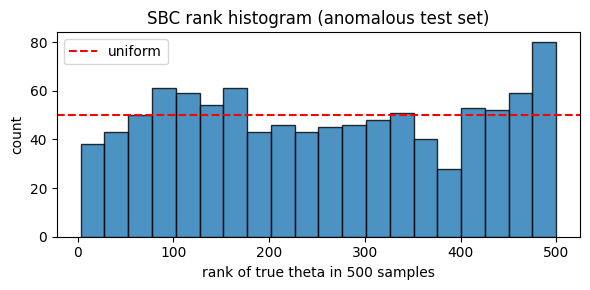

In [14]:
anom_x = x_test[labels == 1]
anom_theta = theta_test[labels == 1].numpy().ravel()

ranks = np.zeros(len(anom_x), dtype=np.int32)
for i in range(len(anom_x)):
    x_i = anom_x[i].to(DEVICE)
    samples = posterior.sample((N_SAMPLES,), x=x_i, show_progress_bars=False)
    s = samples.detach().cpu().numpy().ravel()
    ranks[i] = int((s < anom_theta[i]).sum())

plt.figure(figsize=(6, 3))
plt.hist(ranks, bins=20, edgecolor='k', alpha=0.8)
plt.axhline(len(anom_x) / 20, color='r', linestyle='--', label='uniform')
plt.xlabel(f'rank of true theta in {N_SAMPLES} samples')
plt.ylabel('count')
plt.title('SBC rank histogram (anomalous test set)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Failure mode inspection

Look at the worst 5 false positives and 5 false negatives at a 0.5 score cutoff.

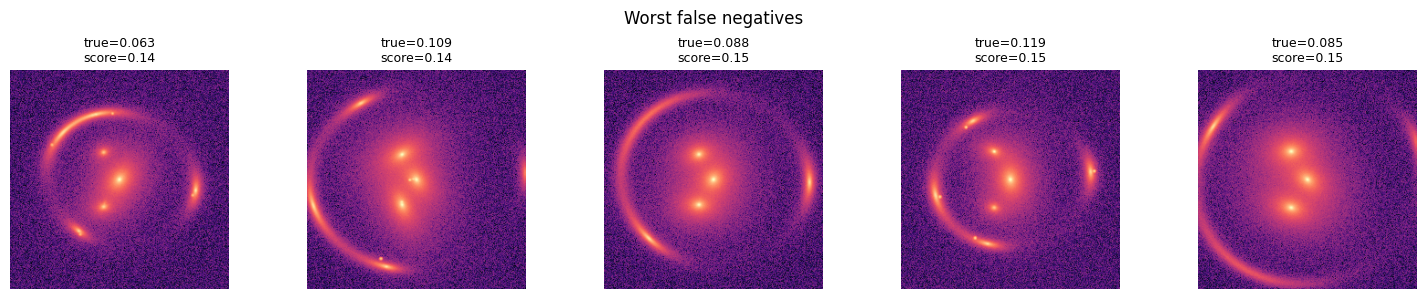

In [15]:
def show_examples(image_indices, title):
    fig, axes = plt.subplots(1, len(image_indices), figsize=(3 * len(image_indices), 3))
    for ax, i in zip(np.atleast_1d(axes), image_indices):
        ax.imshow(x_test[i, 0].numpy(), origin='lower', cmap='magma')
        ax.set_title(f'true={theta_test[i].item():.3f}\nscore={scores[i]:.2f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

fp_idx = np.where((labels == 0) & (scores > 0.5))[0]
fn_idx = np.where((labels == 1) & (scores < 0.5))[0]
fp_idx = fp_idx[np.argsort(-scores[fp_idx])][:5]
fn_idx = fn_idx[np.argsort(scores[fn_idx])][:5]
if len(fp_idx):
    show_examples(fp_idx, 'Worst false positives')
if len(fn_idx):
    show_examples(fn_idx, 'Worst false negatives')